# 04 — Train One Classifier per `.npy` Feature Set

This notebook trains **one classifier for each extracted feature set** and, after training, it:

1. saves the **best classifier**,
2. records **all classifier embeddings** for **train / val / test**,
3. saves predictions, labels, confusion matrices, and reports,
4. runs **t-SNE** and **UMAP** on sampled embeddings to visualize the learned representation.

> **Important for large datasets:** embeddings for each split are saved to `.npy` files on disk.  
> For visualization, the notebook samples up to `MAX_VIS_SAMPLES` points to keep t-SNE / UMAP practical.


In [4]:
from pathlib import Path
import copy
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP is not installed. If needed, run: pip install umap-learn")

# Change this path if your shared folder is different.
PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "output"

SPLIT_DIR = OUTPUT_DIR / "splits"
FEATURE_DIR = OUTPUT_DIR / "features"
RESULTS_DIR = OUTPUT_DIR / "single_feature_classification_results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10
RANDOM_SEED = 42

# Large feature files are loaded by memory map. The scaler is also applied chunk-by-chunk.
SCALER_CHUNK_SIZE = 4096
OVERWRITE_SCALED_FEATURES = False

# Embedding recording / visualization settings.
SAVE_ALL_SPLIT_EMBEDDINGS = True
VISUALIZATION_SOURCE = "test"   # "train", "val", "test", or "all"
MAX_VIS_SAMPLES = 5000
RUN_TSNE = True
RUN_UMAP = True
TSNE_PERPLEXITY = 30

# If your train split is very large, you may reduce this for faster visualization.
MAX_LEGEND_CLASSES = 15

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", device)
print("Feature folder:", FEATURE_DIR)
print("Results folder:", RESULTS_DIR)
print("Visualization source:", VISUALIZATION_SOURCE)
print("Max visualization samples:", MAX_VIS_SAMPLES)


Device: cuda
Feature folder: ..\output\features
Results folder: ..\output\single_feature_classification_results
Visualization source: test
Max visualization samples: 5000


In [14]:
print(y_train[:10])
print(y_train.dtype)
print(np.unique(y_train)[:10])

['Triclosan_05x' 'Mecillinam_05x' 'Nisin_5x' 'Kanamycin_2x'
 'Kanamycin_05x' 'PMB_05x' 'Mecillinam_05x' 'Triclosan_05x' 'Triclosan_2x'
 'PMB_05x']
object
['A22_05x' 'A22_2x' 'Ampicillin_05x' 'Ampicillin_2x' 'Blank'
 'Chloramphenicol_05x' 'Chloramphenicol_2x' 'Control' 'Gramacidin_05x'
 'Gramacidin_2x']


In [15]:
class_names = np.asarray(class_names).astype(str)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

def convert_condition_names_to_idx(y, split_name):
    y = np.asarray(y)

    # If already integer, keep it
    if np.issubdtype(y.dtype, np.integer):
        return y.astype(np.int64)

    # Otherwise convert condition names to integer IDs
    y_str = y.astype(str)

    missing_labels = sorted(set(y_str) - set(class_to_idx.keys()))
    if missing_labels:
        raise ValueError(
            f"{split_name} has labels not found in class_names: {missing_labels[:20]}"
        )

    return np.asarray(
        [class_to_idx[label] for label in y_str],
        dtype=np.int64,
    )

y_train_names = y_train.astype(str)
y_val_names = y_val.astype(str)
y_test_names = y_test.astype(str)

y_train = convert_condition_names_to_idx(y_train, "y_train")
y_val = convert_condition_names_to_idx(y_val, "y_val")
y_test = convert_condition_names_to_idx(y_test, "y_test")

print("Converted label dtype:")
print("y_train:", y_train.dtype, y_train[:10])
print("y_val:", y_val.dtype, y_val[:10])
print("y_test:", y_test.dtype, y_test[:10])

print("\nCheck mapping:")
for i in range(10):
    print(y_train_names[i], "->", y_train[i])

Converted label dtype:
y_train: int64 [29 13 20 12 11 23 13 29 30 23]
y_val: int64 [26 13  7 17 16 21 14 23 29 19]
y_test: int64 [17 12 13 10 13  9  6 30 20 15]

Check mapping:
Triclosan_05x -> 29
Mecillinam_05x -> 13
Nisin_5x -> 20
Kanamycin_2x -> 12
Kanamycin_05x -> 11
PMB_05x -> 23
Mecillinam_05x -> 13
Triclosan_05x -> 29
Triclosan_2x -> 30
PMB_05x -> 23


In [16]:
feature_folders = []

for folder in sorted(FEATURE_DIR.iterdir()):
    if not folder.is_dir():
        continue

    required_files = [
        folder / "train_features.npy",
        folder / "val_features.npy",
        folder / "test_features.npy",
    ]

    if all(path.exists() for path in required_files):
        feature_folders.append(folder)

print("Detected feature folders:")
for folder in feature_folders:
    print("-", folder.name)

if not feature_folders:
    raise FileNotFoundError(
        f"No valid feature folders found in {FEATURE_DIR}. "
        "Run 03_extract_pretrained_features_npy.ipynb first."
    )


Detected feature folders:
- cytoimagenet_efficientnetb0
- densenet121
- efficientnet_b0
- mobilenet_v3_large
- resnet50
- vit_b_16


In [17]:
class FeatureDataset(Dataset):
    def __init__(self, X_features, y_idx):
        self.X = X_features
        self.y = np.asarray(y_idx, dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)
        x = np.ascontiguousarray(x)
        y = int(self.y[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


class SingleFeatureClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.feature_layers = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        embedding = self.feature_layers(x)
        logits = self.classifier(embedding)
        return logits

    def extract_embedding(self, x):
        return self.feature_layers(x)


In [18]:
def iter_feature_chunks(X, chunk_size=SCALER_CHUNK_SIZE):
    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))
        yield start, end, np.asarray(X[start:end], dtype=np.float32)


def fit_scaler_chunked(X_train_raw):
    scaler = StandardScaler()
    for start, end, chunk in iter_feature_chunks(X_train_raw):
        scaler.partial_fit(chunk)
        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_train_raw):
            print(f"  scaler fitted on {end}/{len(X_train_raw)} samples")
    return scaler


def transform_to_memmap(X_raw, scaler, out_file, overwrite=False):
    out_file = Path(out_file)

    if out_file.exists() and not overwrite:
        print("  using existing scaled file:", out_file)
        return np.load(out_file, mmap_mode="r")

    if out_file.exists():
        out_file.unlink()

    out = np.lib.format.open_memmap(
        out_file,
        mode="w+",
        dtype=np.float32,
        shape=X_raw.shape,
    )

    for start, end, chunk in iter_feature_chunks(X_raw):
        out[start:end] = scaler.transform(chunk).astype(np.float32)
        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_raw):
            print(f"  transformed {end}/{len(X_raw)} samples")

    out.flush()
    del out
    return np.load(out_file, mmap_mode="r")


def make_loaders(X_train, X_val, X_test):
    train_dataset = FeatureDataset(X_train, y_train)
    val_dataset = FeatureDataset(X_val, y_val)
    test_dataset = FeatureDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, train_eval_loader, val_loader, test_loader


In [19]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(batch_features)
            loss = criterion(logits, batch_labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_features.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_labels).sum().item()
            total += batch_labels.size(0)

    return total_loss / total, correct / total


def collect_embeddings_predictions(model, loader, split_name, save_dir):
    model.eval()

    embeddings_path = save_dir / f"{split_name}_classifier_embeddings.npy"
    logits_path = save_dir / f"{split_name}_classifier_logits.npy"

    embedding_memmap = None
    logits_memmap = None

    all_preds = []
    all_labels = []
    write_start = 0

    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)

            embeddings = model.extract_embedding(batch_features)
            logits = model.classifier(embeddings)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labels = batch_labels.numpy()

            embeddings = embeddings.cpu().numpy().astype(np.float32)
            logits = logits.cpu().numpy().astype(np.float32)

            if embedding_memmap is None:
                if embeddings_path.exists():
                    embeddings_path.unlink()
                if logits_path.exists():
                    logits_path.unlink()

                embedding_memmap = np.lib.format.open_memmap(
                    embeddings_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), embeddings.shape[1]),
                )
                logits_memmap = np.lib.format.open_memmap(
                    logits_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), logits.shape[1]),
                )

            write_end = write_start + embeddings.shape[0]
            embedding_memmap[write_start:write_end] = embeddings
            logits_memmap[write_start:write_end] = logits
            write_start = write_end

            all_preds.extend(preds)
            all_labels.extend(labels)

    if embedding_memmap is not None:
        embedding_memmap.flush()
        del embedding_memmap

    if logits_memmap is not None:
        logits_memmap.flush()
        del logits_memmap

    pred_idx = np.asarray(all_preds, dtype=np.int64)
    true_idx = np.asarray(all_labels, dtype=np.int64)
    pred_names = np.asarray([class_names[i] for i in pred_idx])
    true_names = np.asarray([class_names[i] for i in true_idx])

    np.save(save_dir / f"{split_name}_predictions_idx.npy", pred_idx)
    np.save(save_dir / f"{split_name}_predictions_names.npy", pred_names)
    np.save(save_dir / f"{split_name}_true_idx.npy", true_idx)
    np.save(save_dir / f"{split_name}_true_names.npy", true_names)

    return {
        "embeddings_path": embeddings_path,
        "logits_path": logits_path,
        "pred_idx": pred_idx,
        "true_idx": true_idx,
        "pred_names": pred_names,
        "true_names": true_names,
    }


def random_sample_indices(n_samples, max_samples, random_seed=RANDOM_SEED):
    if n_samples <= max_samples:
        return np.arange(n_samples)
    rng = np.random.default_rng(random_seed)
    return np.sort(rng.choice(n_samples, size=max_samples, replace=False))


def load_visualization_sample(result_dir, source="test", max_samples=MAX_VIS_SAMPLES):
    if source not in {"train", "val", "test", "all"}:
        raise ValueError("source must be one of: train, val, test, all")

    if source in {"train", "val", "test"}:
        emb = np.load(result_dir / f"{source}_classifier_embeddings.npy", mmap_mode="r")
        true_idx = np.load(result_dir / f"{source}_true_idx.npy")
        pred_idx = np.load(result_dir / f"{source}_predictions_idx.npy")

        sample_idx = random_sample_indices(len(true_idx), max_samples)

        sampled_embeddings = np.asarray(emb[sample_idx], dtype=np.float32)
        sampled_true_idx = true_idx[sample_idx]
        sampled_pred_idx = pred_idx[sample_idx]
        sampled_splits = np.array([source] * len(sample_idx))

        return sampled_embeddings, sampled_true_idx, sampled_pred_idx, sampled_splits

    split_names = ["train", "val", "test"]
    split_sizes = []
    for split_name in split_names:
        true_idx = np.load(result_dir / f"{split_name}_true_idx.npy")
        split_sizes.append(len(true_idx))

    total_size = int(np.sum(split_sizes))
    if total_size <= max_samples:
        sample_counts = split_sizes
    else:
        proportions = np.asarray(split_sizes, dtype=float) / total_size
        sample_counts = np.floor(proportions * max_samples).astype(int)
        sample_counts = np.maximum(sample_counts, 1)

        while sample_counts.sum() > max_samples:
            largest = np.argmax(sample_counts)
            if sample_counts[largest] > 1:
                sample_counts[largest] -= 1
            else:
                break

        while sample_counts.sum() < max_samples:
            room = np.asarray(split_sizes) - sample_counts
            largest_room = np.argmax(room)
            if room[largest_room] > 0:
                sample_counts[largest_room] += 1
            else:
                break

    emb_list = []
    true_list = []
    pred_list = []
    split_list = []

    for split_name, split_size, split_count in zip(split_names, split_sizes, sample_counts):
        emb = np.load(result_dir / f"{split_name}_classifier_embeddings.npy", mmap_mode="r")
        true_idx = np.load(result_dir / f"{split_name}_true_idx.npy")
        pred_idx = np.load(result_dir / f"{split_name}_predictions_idx.npy")

        sample_idx = random_sample_indices(split_size, int(split_count))

        emb_list.append(np.asarray(emb[sample_idx], dtype=np.float32))
        true_list.append(true_idx[sample_idx])
        pred_list.append(pred_idx[sample_idx])
        split_list.append(np.array([split_name] * len(sample_idx)))

    sampled_embeddings = np.concatenate(emb_list, axis=0)
    sampled_true_idx = np.concatenate(true_list, axis=0)
    sampled_pred_idx = np.concatenate(pred_list, axis=0)
    sampled_splits = np.concatenate(split_list, axis=0)

    return sampled_embeddings, sampled_true_idx, sampled_pred_idx, sampled_splits


def plot_embedding_by_label(coords, labels, out_file, title):
    unique_labels = np.unique(labels)

    plt.figure(figsize=(10, 8))
    for label_idx in unique_labels:
        mask = labels == label_idx
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=12,
            alpha=0.7,
            label=str(class_names[label_idx]),
        )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    if len(unique_labels) <= MAX_LEGEND_CLASSES:
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_embedding_by_correctness(coords, true_idx, pred_idx, out_file, title):
    correct = true_idx == pred_idx

    plt.figure(figsize=(10, 8))

    for is_correct, label in [(True, "Correct"), (False, "Incorrect")]:
        mask = correct == is_correct
        if np.any(mask):
            plt.scatter(
                coords[mask, 0],
                coords[mask, 1],
                s=12,
                alpha=0.7,
                label=label,
            )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def run_visualizations(result_dir, feature_name, source=VISUALIZATION_SOURCE, max_samples=MAX_VIS_SAMPLES):
    sampled_embeddings, sampled_true_idx, sampled_pred_idx, sampled_splits = load_visualization_sample(
        result_dir,
        source=source,
        max_samples=max_samples,
    )

    sampled_true_names = np.asarray([class_names[i] for i in sampled_true_idx])
    sampled_pred_names = np.asarray([class_names[i] for i in sampled_pred_idx])
    sampled_correct = sampled_true_idx == sampled_pred_idx

    metadata_df = pd.DataFrame({
        "split": sampled_splits,
        "true_idx": sampled_true_idx,
        "true_name": sampled_true_names,
        "pred_idx": sampled_pred_idx,
        "pred_name": sampled_pred_names,
        "correct": sampled_correct,
    })

    metadata_df.to_csv(result_dir / f"visualization_sample_metadata_{source}.csv", index=False)
    np.save(result_dir / f"visualization_sample_embeddings_{source}.npy", sampled_embeddings)

    if RUN_TSNE:
        print(f"Running t-SNE for {feature_name} ({source}, n={len(sampled_embeddings)}) ...")
        tsne = TSNE(
            n_components=2,
            perplexity=min(TSNE_PERPLEXITY, max(5, len(sampled_embeddings) // 10)),
            init="pca",
            learning_rate="auto",
            random_state=RANDOM_SEED,
        )
        tsne_coords = tsne.fit_transform(sampled_embeddings)

        tsne_df = metadata_df.copy()
        tsne_df["x"] = tsne_coords[:, 0]
        tsne_df["y"] = tsne_coords[:, 1]
        tsne_df.to_csv(result_dir / f"tsne_{source}_coordinates.csv", index=False)
        np.save(result_dir / f"tsne_{source}_coordinates.npy", tsne_coords)

        plot_embedding_by_label(
            tsne_coords,
            sampled_true_idx,
            result_dir / f"tsne_{source}_by_true_label.png",
            title=f"t-SNE — {feature_name} — {source} embeddings (colored by true label)",
        )
        plot_embedding_by_correctness(
            tsne_coords,
            sampled_true_idx,
            sampled_pred_idx,
            result_dir / f"tsne_{source}_by_correctness.png",
            title=f"t-SNE — {feature_name} — {source} embeddings (correct vs incorrect)",
        )

    if RUN_UMAP:
        if not HAS_UMAP:
            print("Skipping UMAP because umap-learn is not installed.")
        else:
            print(f"Running UMAP for {feature_name} ({source}, n={len(sampled_embeddings)}) ...")
            reducer = umap.UMAP(
                n_neighbors=15,
                min_dist=0.1,
                n_components=2,
                metric="euclidean",
                random_state=RANDOM_SEED,
            )
            umap_coords = reducer.fit_transform(sampled_embeddings)

            umap_df = metadata_df.copy()
            umap_df["x"] = umap_coords[:, 0]
            umap_df["y"] = umap_coords[:, 1]
            umap_df.to_csv(result_dir / f"umap_{source}_coordinates.csv", index=False)
            np.save(result_dir / f"umap_{source}_coordinates.npy", umap_coords)

            plot_embedding_by_label(
                umap_coords,
                sampled_true_idx,
                result_dir / f"umap_{source}_by_true_label.png",
                title=f"UMAP — {feature_name} — {source} embeddings (colored by true label)",
            )
            plot_embedding_by_correctness(
                umap_coords,
                sampled_true_idx,
                sampled_pred_idx,
                result_dir / f"umap_{source}_by_correctness.png",
                title=f"UMAP — {feature_name} — {source} embeddings (correct vs incorrect)",
            )


In [20]:
def train_classifier_for_feature_folder(feature_folder):
    feature_name = feature_folder.name
    result_dir = RESULTS_DIR / feature_name
    result_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print("Training classifier for feature:", feature_name)
    print("=" * 100)

    X_train_raw = np.load(feature_folder / "train_features.npy", mmap_mode="r")
    X_val_raw = np.load(feature_folder / "val_features.npy", mmap_mode="r")
    X_test_raw = np.load(feature_folder / "test_features.npy", mmap_mode="r")

    print("Raw feature shapes:")
    print("  train:", X_train_raw.shape, X_train_raw.dtype)
    print("  val:", X_val_raw.shape, X_val_raw.dtype)
    print("  test:", X_test_raw.shape, X_test_raw.dtype)

    scaler = fit_scaler_chunked(X_train_raw)

    with open(result_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    X_train_scaled = transform_to_memmap(
        X_train_raw,
        scaler,
        result_dir / "train_features_scaled.npy",
        overwrite=OVERWRITE_SCALED_FEATURES,
    )

    X_val_scaled = transform_to_memmap(
        X_val_raw,
        scaler,
        result_dir / "val_features_scaled.npy",
        overwrite=OVERWRITE_SCALED_FEATURES,
    )

    X_test_scaled = transform_to_memmap(
        X_test_raw,
        scaler,
        result_dir / "test_features_scaled.npy",
        overwrite=OVERWRITE_SCALED_FEATURES,
    )

    train_loader, train_eval_loader, val_loader, test_loader = make_loaders(
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,
    )

    input_dim = X_train_scaled.shape[1]

    model = SingleFeatureClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = []
    best_val_acc = -1.0
    best_state = None
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        val_loss, val_acc = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }

        history.append(row)

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(result_dir / "training_history.csv", index=False)

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(
        {
            "feature_name": feature_name,
            "input_dim": input_dim,
            "num_classes": num_classes,
            "class_names": class_names.tolist(),
            "best_epoch": best_epoch,
            "best_val_acc": best_val_acc,
            "model_state_dict": model.state_dict(),
        },
        result_dir / "best_classifier.pt",
    )

    split_outputs = {}

    if SAVE_ALL_SPLIT_EMBEDDINGS:
        split_outputs["train"] = collect_embeddings_predictions(
            model,
            train_eval_loader,
            split_name="train",
            save_dir=result_dir,
        )

        split_outputs["val"] = collect_embeddings_predictions(
            model,
            val_loader,
            split_name="val",
            save_dir=result_dir,
        )

        split_outputs["test"] = collect_embeddings_predictions(
            model,
            test_loader,
            split_name="test",
            save_dir=result_dir,
        )
    else:
        split_outputs["test"] = collect_embeddings_predictions(
            model,
            test_loader,
            split_name="test",
            save_dir=result_dir,
        )

    test_preds = split_outputs["test"]["pred_idx"]
    test_labels = split_outputs["test"]["true_idx"]

    test_acc = accuracy_score(test_labels, test_preds)

    macro_f1 = f1_score(
        test_labels,
        test_preds,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        test_labels,
        test_preds,
        average="weighted",
        zero_division=0,
    )

    report_text = classification_report(
        test_labels,
        test_preds,
        labels=np.arange(num_classes),
        target_names=class_names,
        zero_division=0,
    )

    cm = confusion_matrix(
        test_labels,
        test_preds,
        labels=np.arange(num_classes),
    )

    np.save(result_dir / "confusion_matrix.npy", cm)

    with open(result_dir / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)

    checkpoint = torch.load(result_dir / "best_classifier.pt", map_location="cpu")
    checkpoint["test_acc"] = test_acc
    checkpoint["macro_f1"] = macro_f1
    checkpoint["weighted_f1"] = weighted_f1
    torch.save(checkpoint, result_dir / "best_classifier.pt")

    print("\nTest results for:", feature_name)
    print("Best epoch:", best_epoch)
    print("Best validation accuracy:", best_val_acc)
    print("Test accuracy:", test_acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print("\nClassification report:")
    print(report_text)

    run_visualizations(
        result_dir=result_dir,
        feature_name=feature_name,
        source=VISUALIZATION_SOURCE,
        max_samples=MAX_VIS_SAMPLES,
    )

    summary_row = {
        "feature_name": feature_name,
        "input_dim": input_dim,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "result_dir": str(result_dir),
    }

    return summary_row


Training classifier for feature: cytoimagenet_efficientnetb0
Raw feature shapes:
  train: (82434, 5120) float32
  val: (27478, 5120) float32
  test: (27478, 5120) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  using existing scaled file: ..\output\single_feature_classification_results\cytoimagenet_efficientnetb0\train_features_scaled.npy
  using existing scaled file: ..\output\single_feature_classification_results\cytoimagenet_efficientnetb0\val_features_scaled.npy
  using existing scaled file: ..\output\single_feature_classification_results\cytoimagenet_efficientnetb0\test_features_scaled.npy


C:\Users\HaohuanLi\AppData\Local\Temp\ipykernel_5396\3191182261.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


Epoch [01/50] Train Loss: 2.0717 Train Acc: 0.3451 Val Loss: 1.7174 Val Acc: 0.4414
Epoch [02/50] Train Loss: 1.7651 Train Acc: 0.4244 Val Loss: 1.6117 Val Acc: 0.4648
Epoch [03/50] Train Loss: 1.6747 Train Acc: 0.4480 Val Loss: 1.5532 Val Acc: 0.4851
Epoch [04/50] Train Loss: 1.6121 Train Acc: 0.4657 Val Loss: 1.5147 Val Acc: 0.4919
Epoch [05/50] Train Loss: 1.5660 Train Acc: 0.4779 Val Loss: 1.4755 Val Acc: 0.5055
Epoch [06/50] Train Loss: 1.5263 Train Acc: 0.4916 Val Loss: 1.4526 Val Acc: 0.5127
Epoch [07/50] Train Loss: 1.4889 Train Acc: 0.5000 Val Loss: 1.4349 Val Acc: 0.5194
Epoch [08/50] Train Loss: 1.4662 Train Acc: 0.5094 Val Loss: 1.4270 Val Acc: 0.5190
Epoch [09/50] Train Loss: 1.4358 Train Acc: 0.5150 Val Loss: 1.4202 Val Acc: 0.5227
Epoch [10/50] Train Loss: 1.4146 Train Acc: 0.5221 Val Loss: 1.3843 Val Acc: 0.5335
Epoch [11/50] Train Loss: 1.3947 Train Acc: 0.5306 Val Loss: 1.3785 Val Acc: 0.5319
Epoch [12/50] Train Loss: 1.3719 Train Acc: 0.5359 Val Loss: 1.3732 Val Acc:

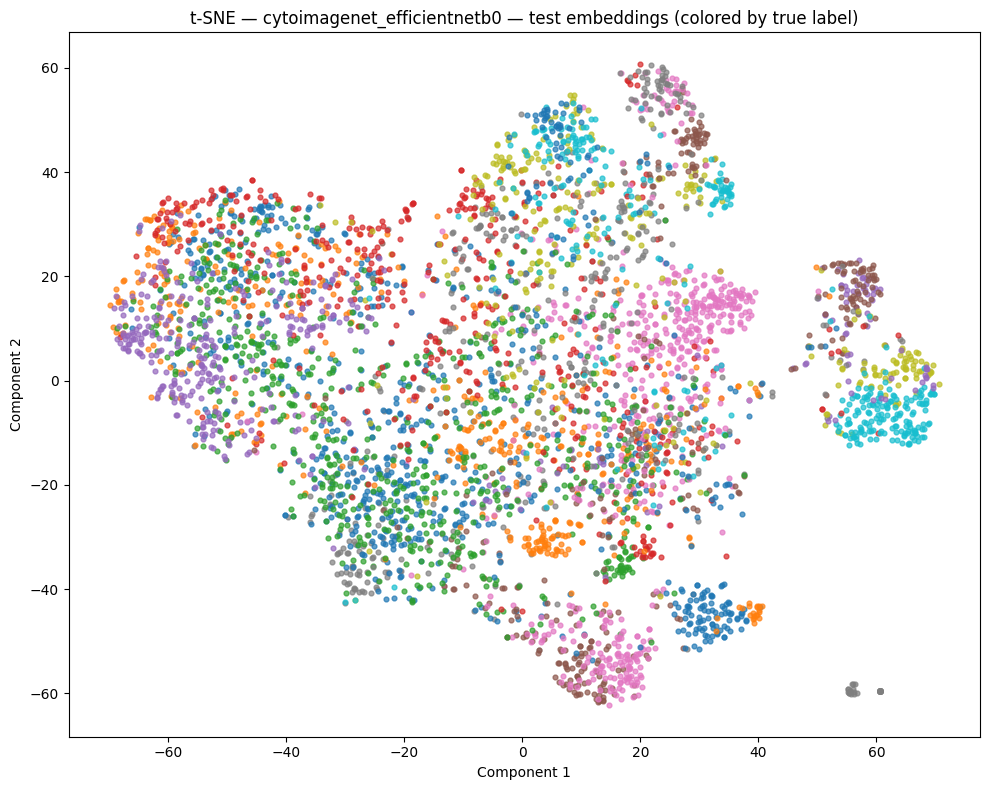

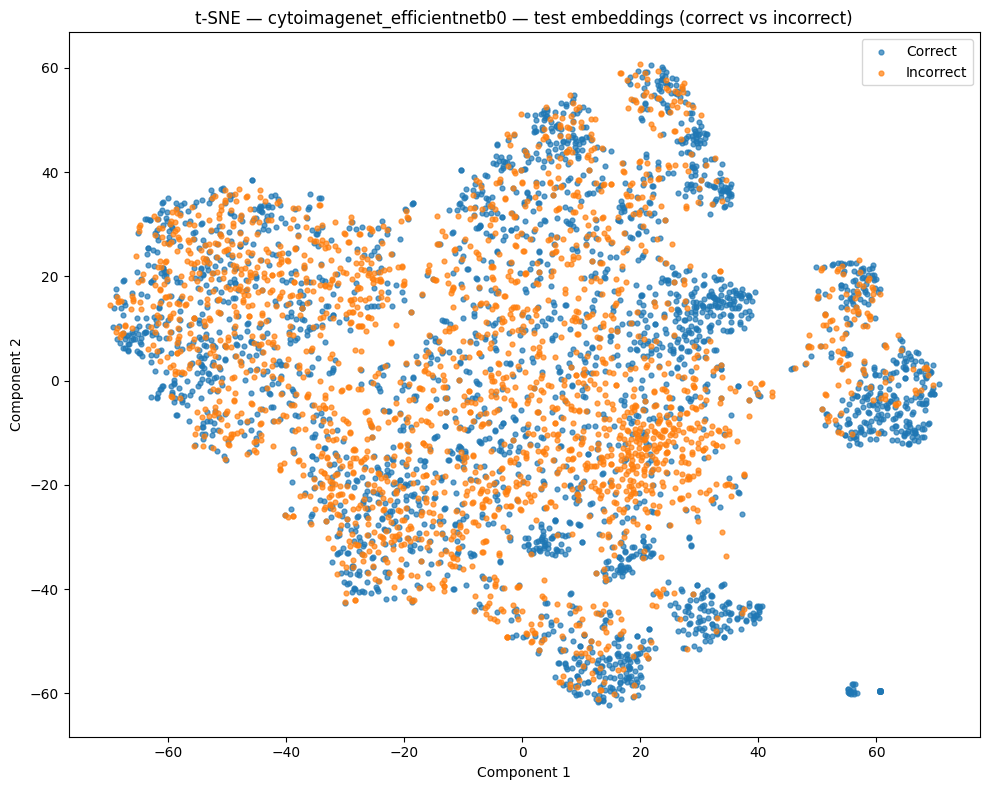

Running UMAP for cytoimagenet_efficientnetb0 (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


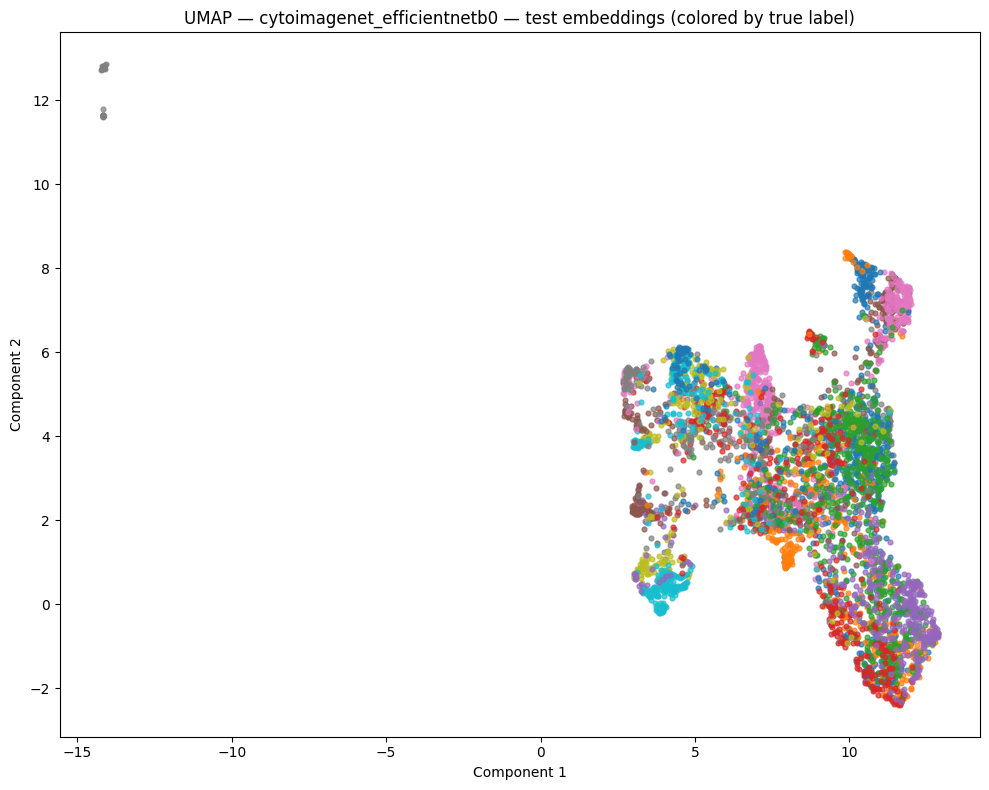

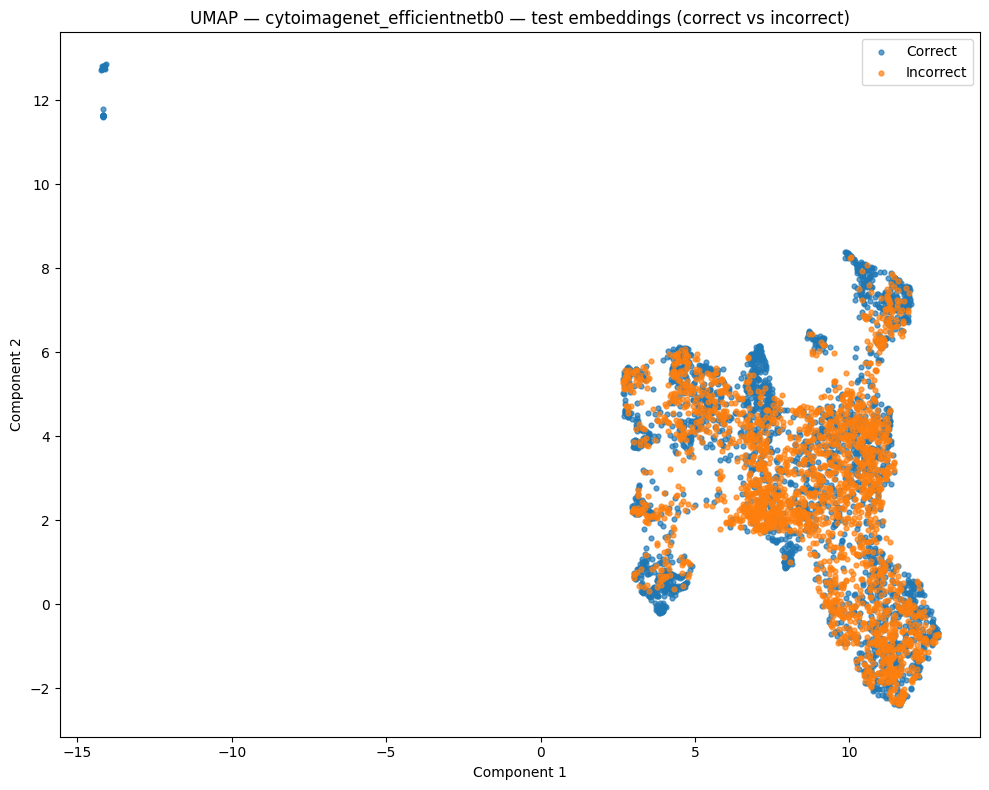


Training classifier for feature: densenet121
Raw feature shapes:
  train: (82434, 4096) float32
  val: (27478, 4096) float32
  test: (27478, 4096) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  transformed 40960/82434 samples
  transformed 81920/82434 samples
  transformed 82434/82434 samples
  transformed 27478/27478 samples
  transformed 27478/27478 samples
Epoch [01/50] Train Loss: 1.3019 Train Acc: 0.5631 Val Loss: 0.8344 Val Acc: 0.7089
Epoch [02/50] Train Loss: 0.8616 Train Acc: 0.6972 Val Loss: 0.7123 Val Acc: 0.7474
Epoch [03/50] Train Loss: 0.7507 Train Acc: 0.7347 Val Loss: 0.6471 Val Acc: 0.7709
Epoch [04/50] Train Loss: 0.6781 Train Acc: 0.7584 Val Loss: 0.6418 Val Acc: 0.7694
Epoch [05/50] Train Loss: 0.6205 Train Acc: 0.7798 Val Loss: 0.6177 Val Acc: 0.7767
Epoch [06/50] Train Loss: 0.5784 Train Acc: 0.7943 Val Loss: 0.5877 Val Acc: 0.7920
Epoch [07/50] Train Loss: 0.5422 Train Acc: 0.8061 Va

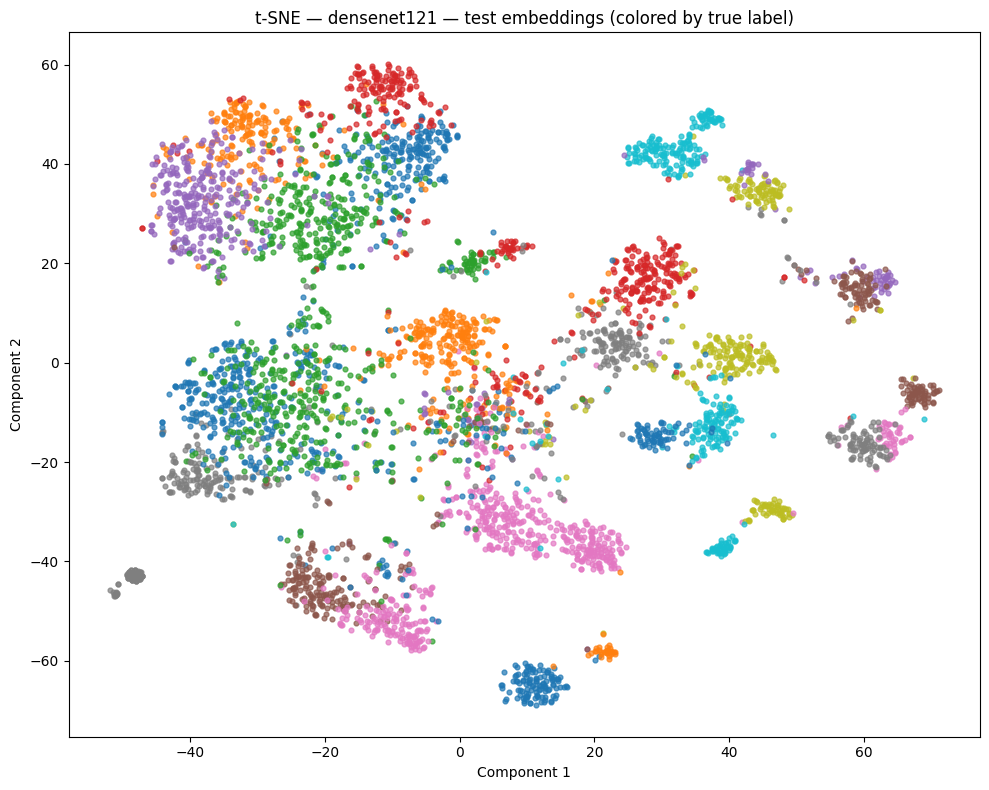

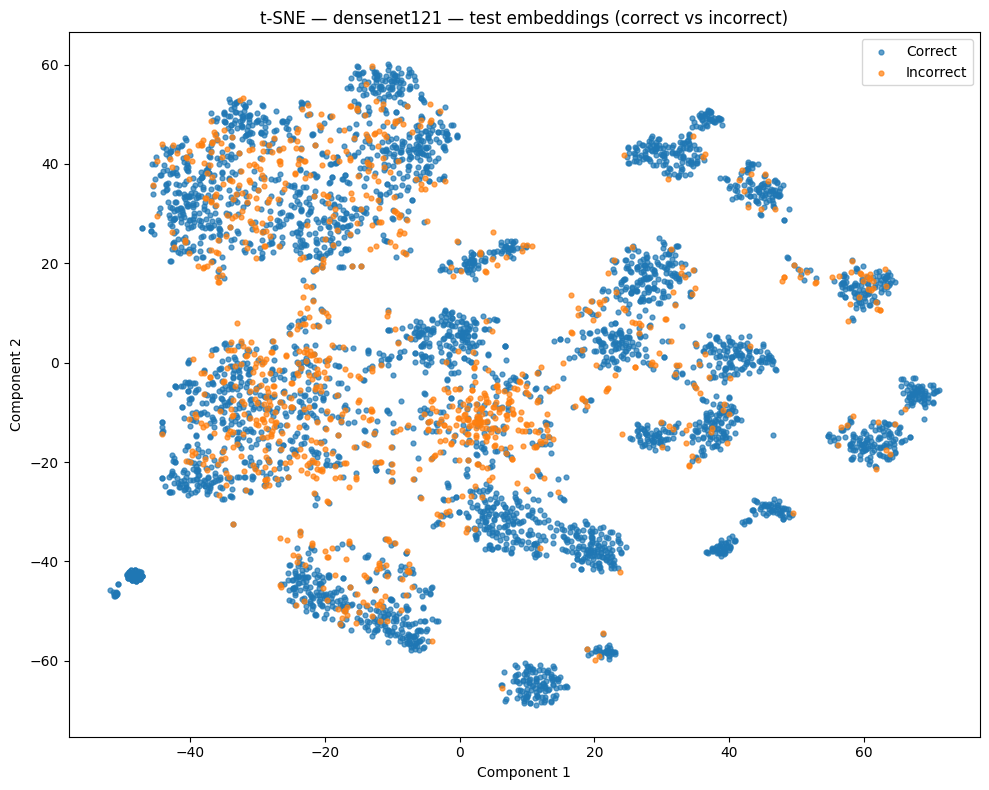

Running UMAP for densenet121 (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


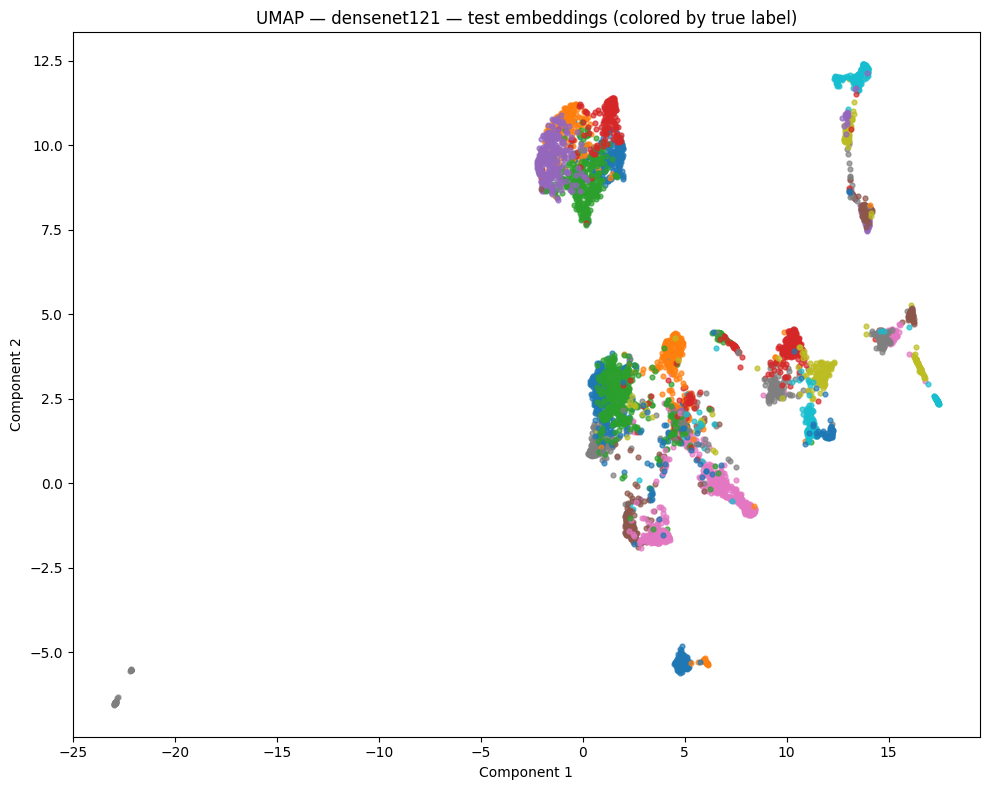

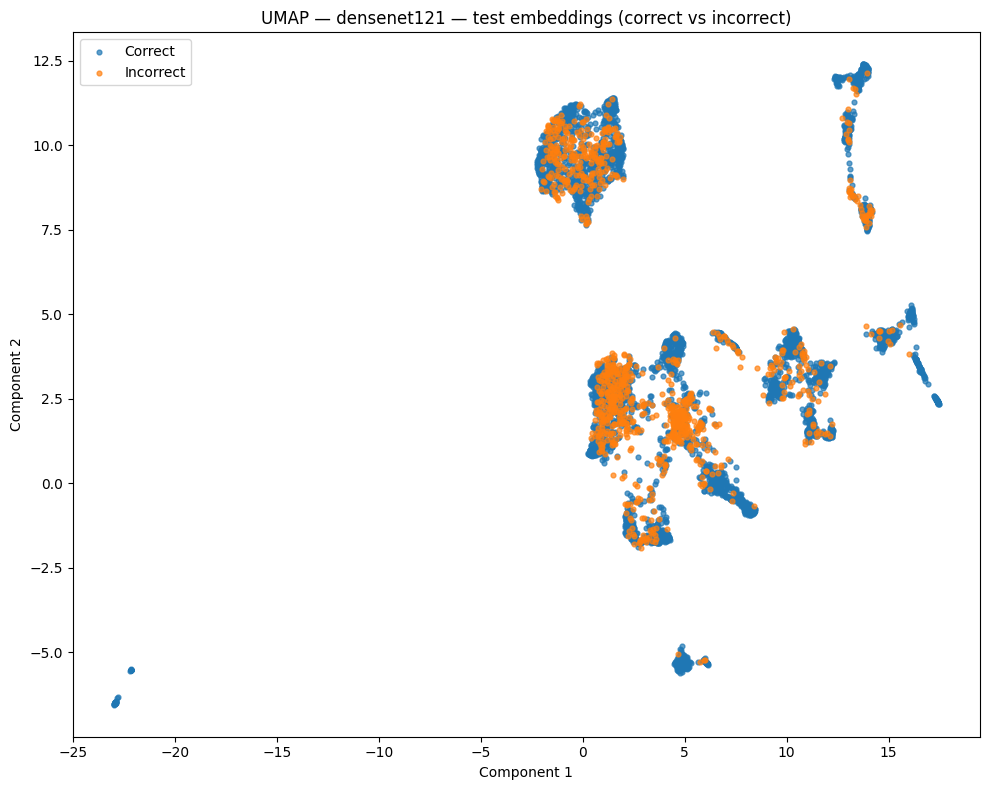


Training classifier for feature: efficientnet_b0
Raw feature shapes:
  train: (82434, 5120) float32
  val: (27478, 5120) float32
  test: (27478, 5120) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  transformed 40960/82434 samples
  transformed 81920/82434 samples
  transformed 82434/82434 samples
  transformed 27478/27478 samples
  transformed 27478/27478 samples
Epoch [01/50] Train Loss: 1.3595 Train Acc: 0.5433 Val Loss: 0.9790 Val Acc: 0.6531
Epoch [02/50] Train Loss: 0.9636 Train Acc: 0.6665 Val Loss: 0.8412 Val Acc: 0.7025
Epoch [03/50] Train Loss: 0.8555 Train Acc: 0.6991 Val Loss: 0.8111 Val Acc: 0.7118
Epoch [04/50] Train Loss: 0.7780 Train Acc: 0.7255 Val Loss: 0.7790 Val Acc: 0.7247
Epoch [05/50] Train Loss: 0.7176 Train Acc: 0.7458 Val Loss: 0.7796 Val Acc: 0.7232
Epoch [06/50] Train Loss: 0.6700 Train Acc: 0.7614 Val Loss: 0.7294 Val Acc: 0.7443
Epoch [07/50] Train Loss: 0.6276 Train Acc: 0.774

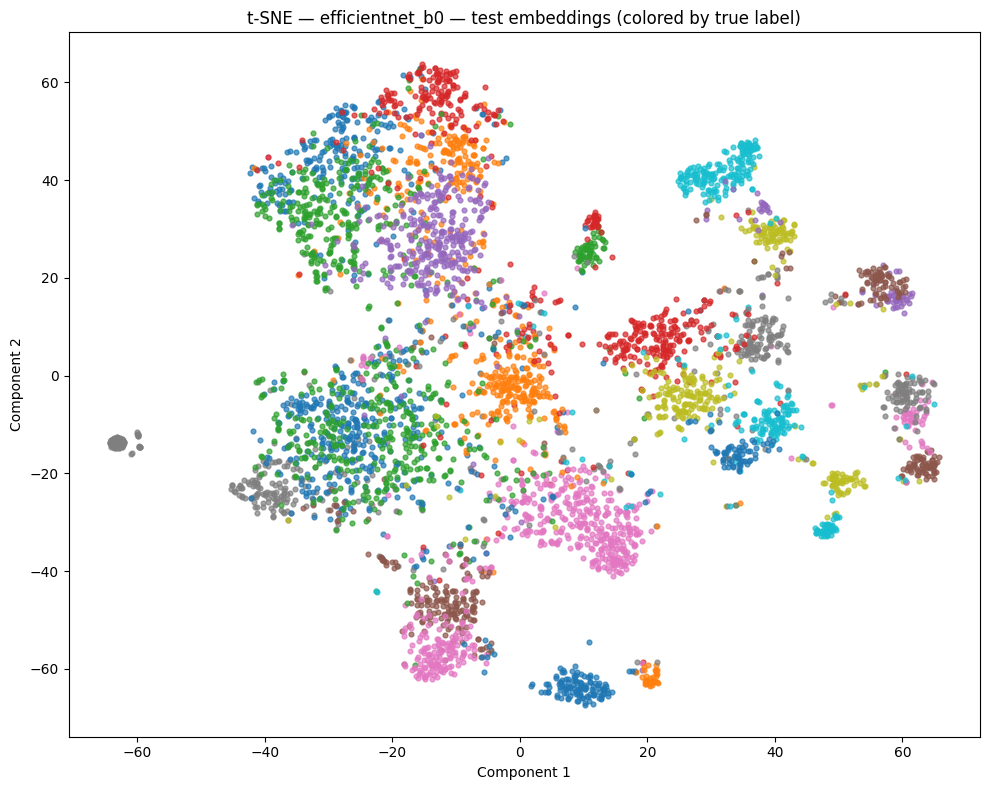

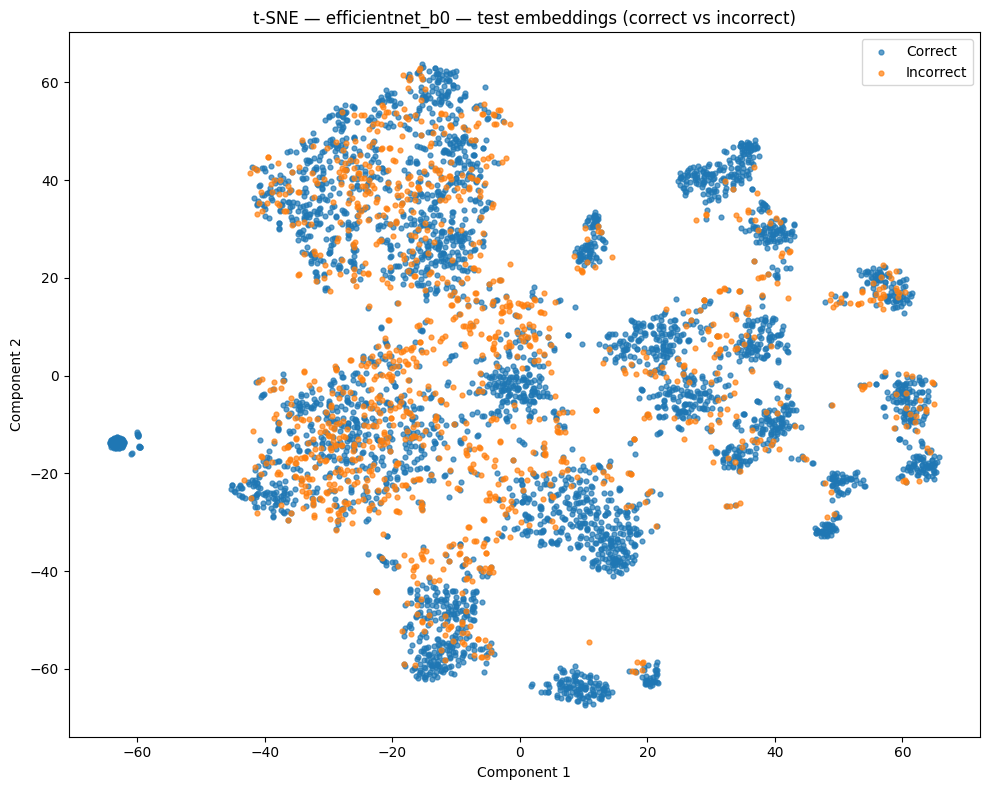

Running UMAP for efficientnet_b0 (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


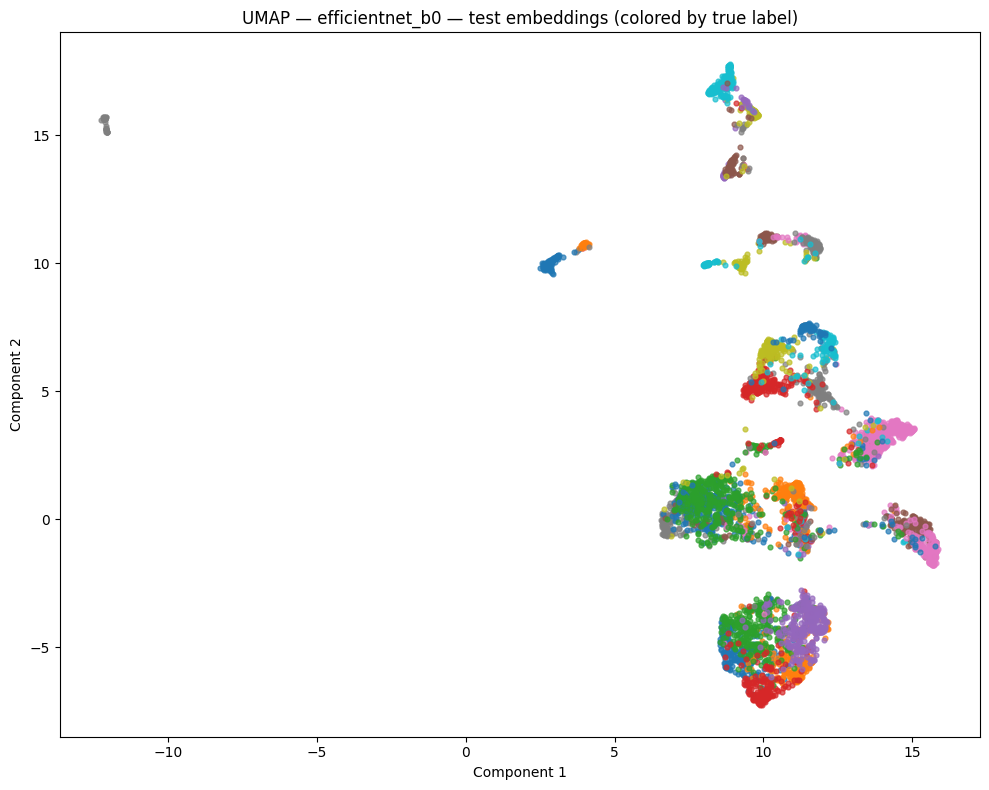

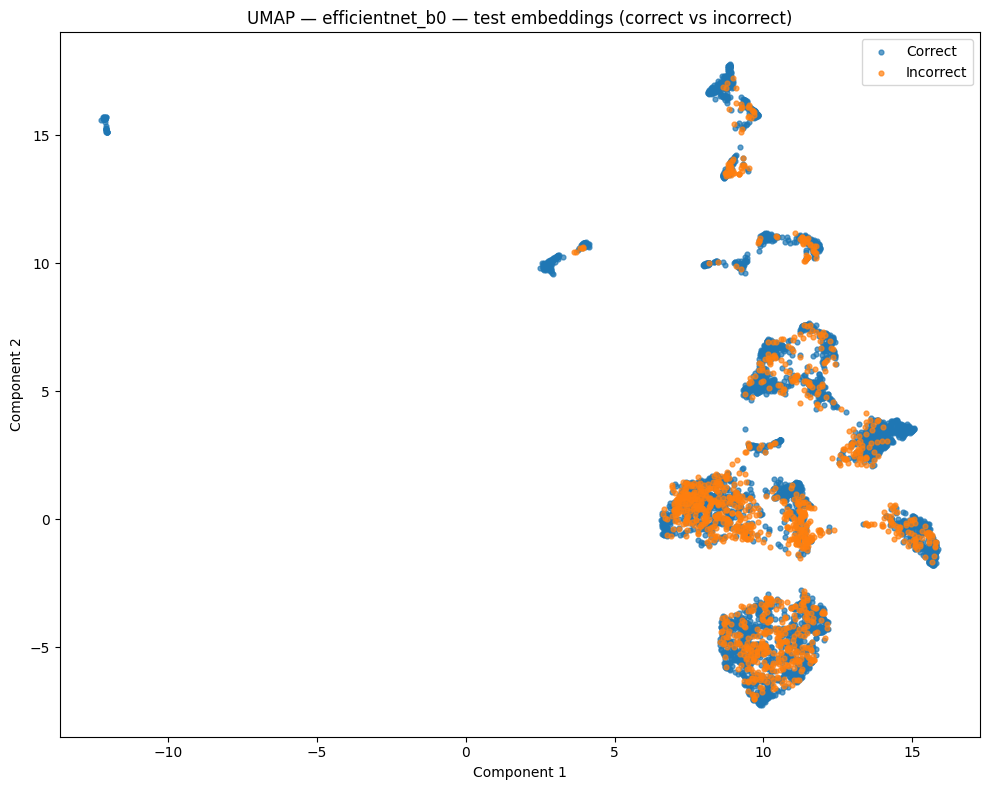


Training classifier for feature: mobilenet_v3_large
Raw feature shapes:
  train: (82434, 3840) float32
  val: (27478, 3840) float32
  test: (27478, 3840) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  transformed 40960/82434 samples
  transformed 81920/82434 samples
  transformed 82434/82434 samples
  transformed 27478/27478 samples
  transformed 27478/27478 samples
Epoch [01/50] Train Loss: 1.3342 Train Acc: 0.5499 Val Loss: 0.9546 Val Acc: 0.6653
Epoch [02/50] Train Loss: 0.9328 Train Acc: 0.6756 Val Loss: 0.8113 Val Acc: 0.7136
Epoch [03/50] Train Loss: 0.8180 Train Acc: 0.7115 Val Loss: 0.7958 Val Acc: 0.7150
Epoch [04/50] Train Loss: 0.7367 Train Acc: 0.7392 Val Loss: 0.7350 Val Acc: 0.7431
Epoch [05/50] Train Loss: 0.6858 Train Acc: 0.7561 Val Loss: 0.7231 Val Acc: 0.7434
Epoch [06/50] Train Loss: 0.6299 Train Acc: 0.7743 Val Loss: 0.7055 Val Acc: 0.7516
Epoch [07/50] Train Loss: 0.5856 Train Acc: 0.

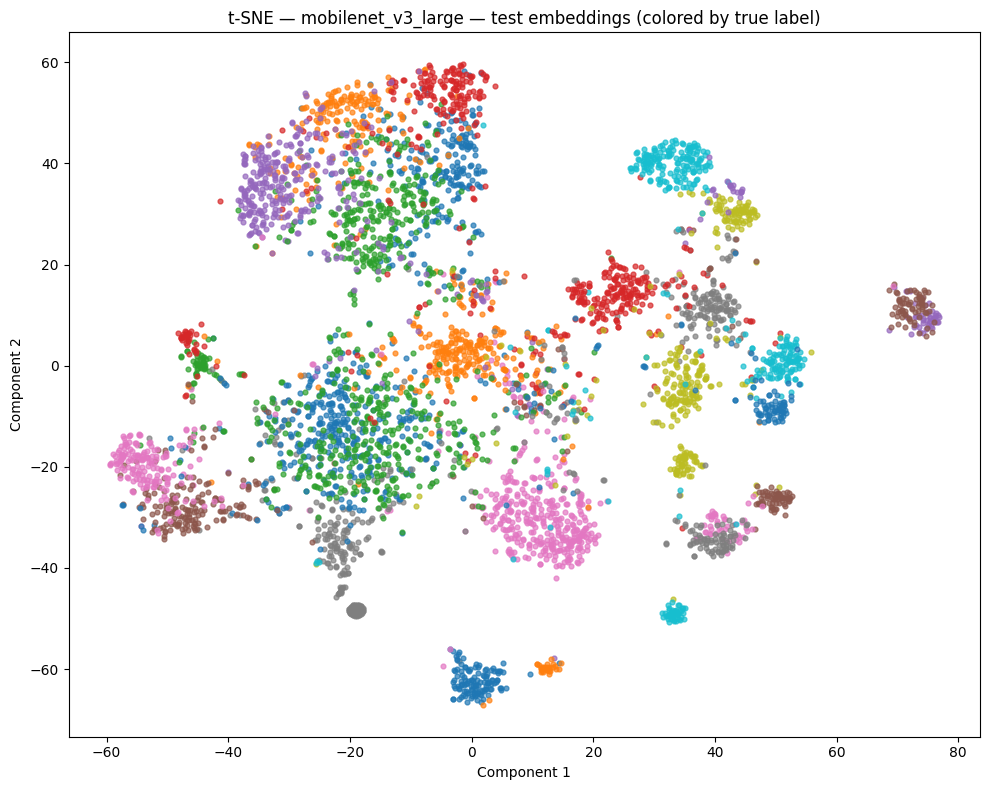

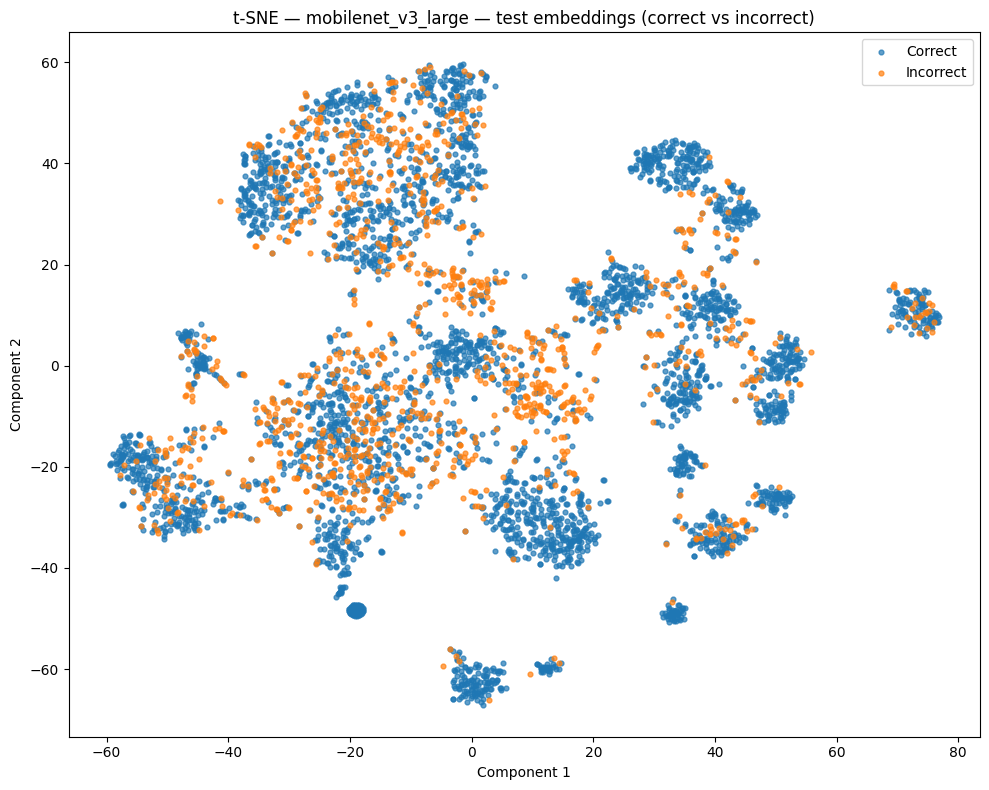

Running UMAP for mobilenet_v3_large (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


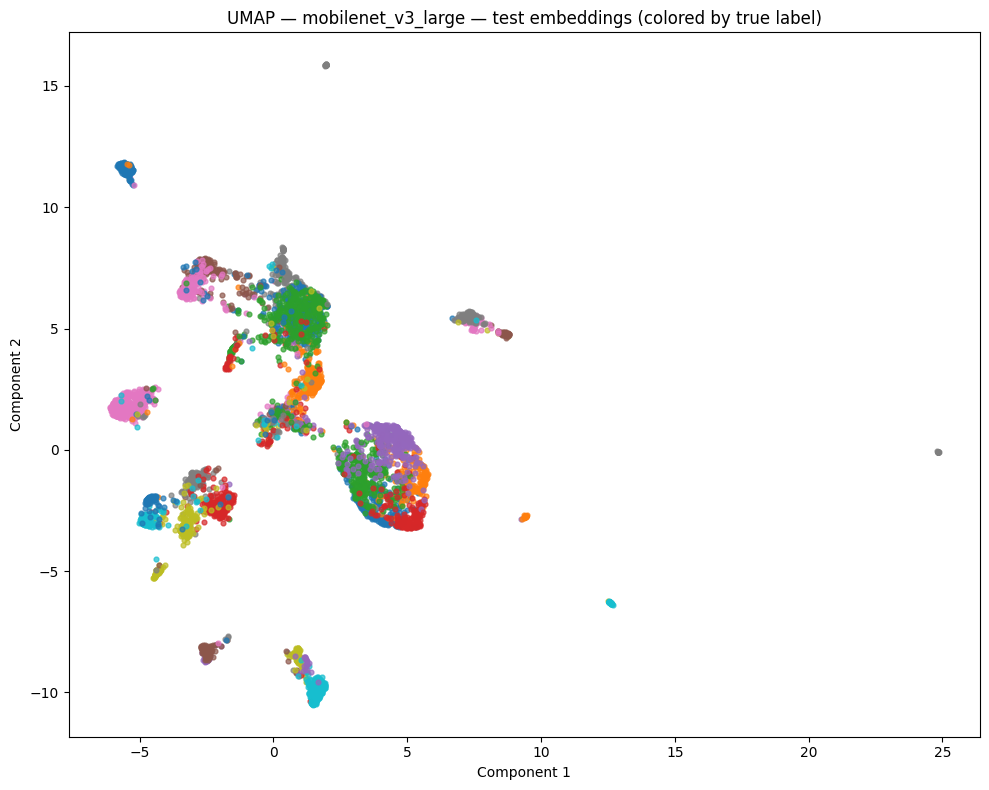

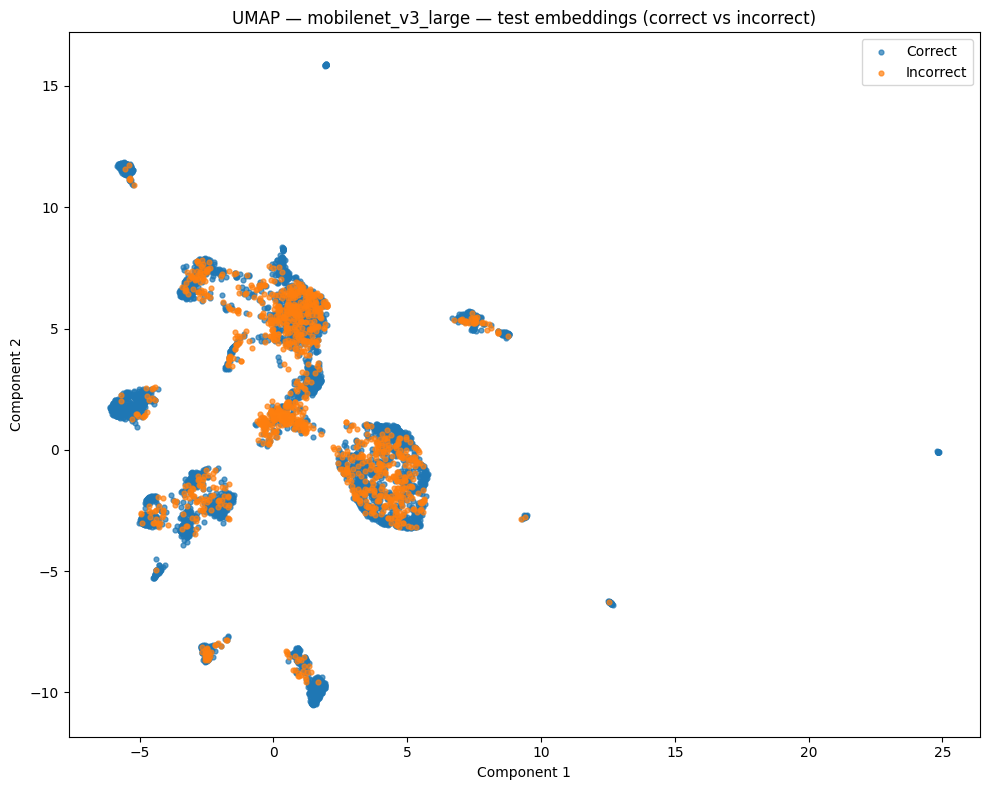


Training classifier for feature: resnet50
Raw feature shapes:
  train: (82434, 8192) float32
  val: (27478, 8192) float32
  test: (27478, 8192) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  transformed 40960/82434 samples
  transformed 81920/82434 samples
  transformed 82434/82434 samples
  transformed 27478/27478 samples
  transformed 27478/27478 samples
Epoch [01/50] Train Loss: 1.4978 Train Acc: 0.4976 Val Loss: 1.0734 Val Acc: 0.6249
Epoch [02/50] Train Loss: 1.0255 Train Acc: 0.6409 Val Loss: 0.9789 Val Acc: 0.6538
Epoch [03/50] Train Loss: 0.8518 Train Acc: 0.6962 Val Loss: 0.9275 Val Acc: 0.6777
Epoch [04/50] Train Loss: 0.7274 Train Acc: 0.7377 Val Loss: 0.9159 Val Acc: 0.6861
Epoch [05/50] Train Loss: 0.6272 Train Acc: 0.7726 Val Loss: 0.9300 Val Acc: 0.6873
Epoch [06/50] Train Loss: 0.5367 Train Acc: 0.8044 Val Loss: 0.9647 Val Acc: 0.6918
Epoch [07/50] Train Loss: 0.4679 Train Acc: 0.8293 Val L

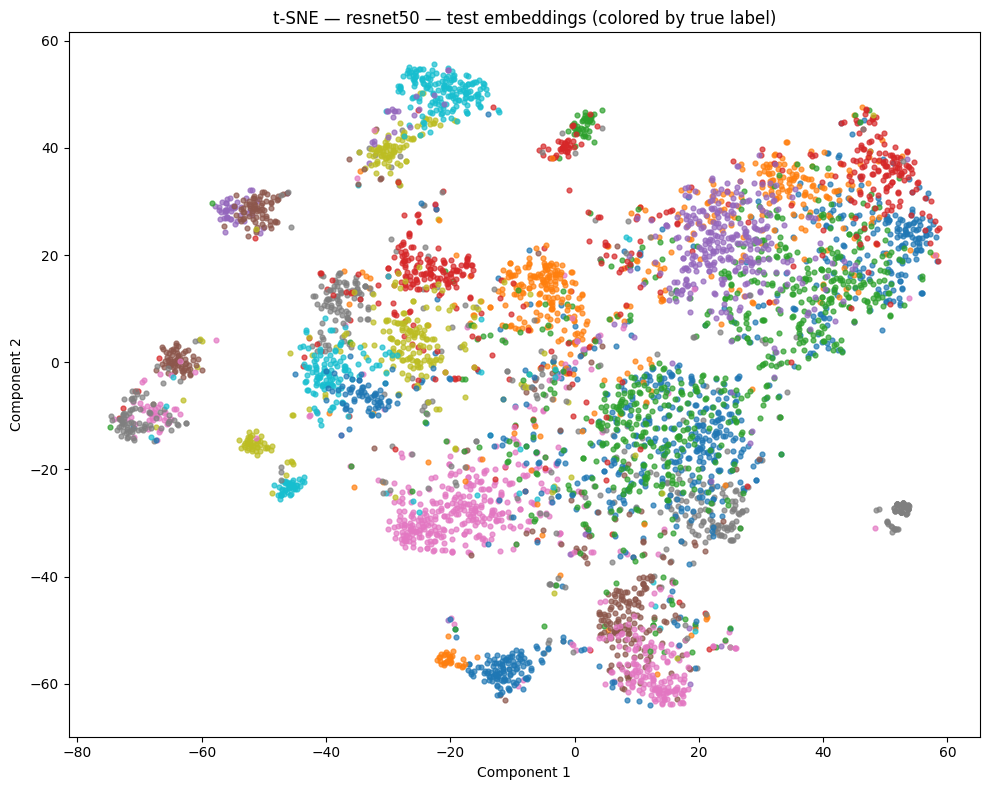

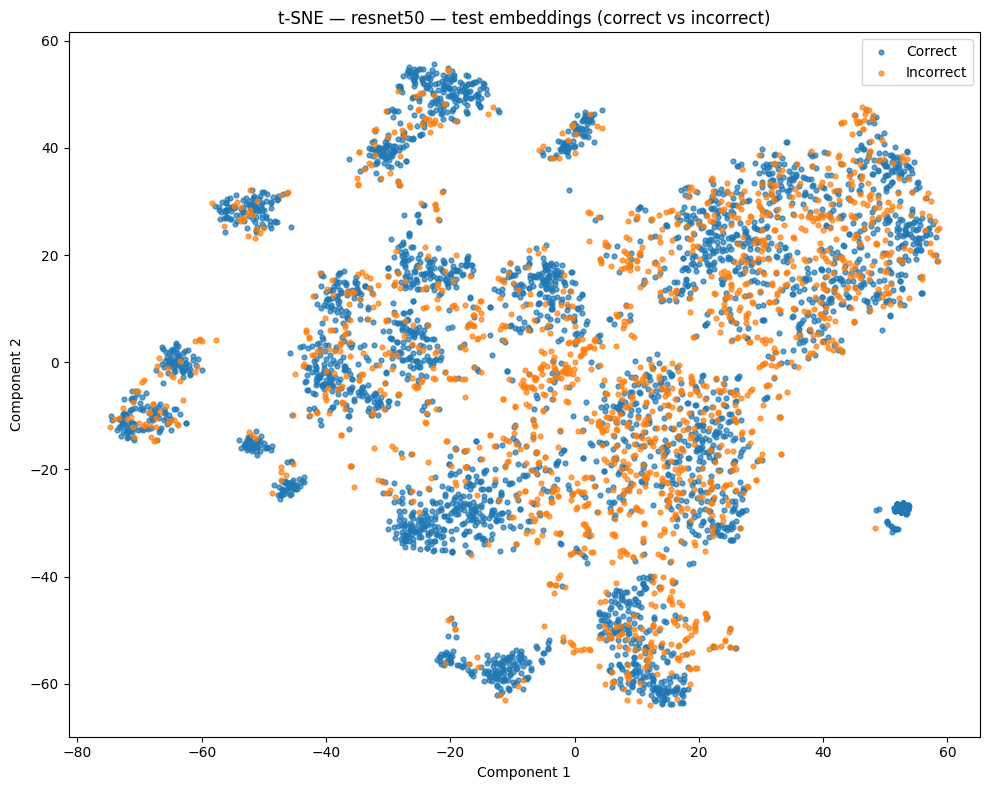

Running UMAP for resnet50 (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


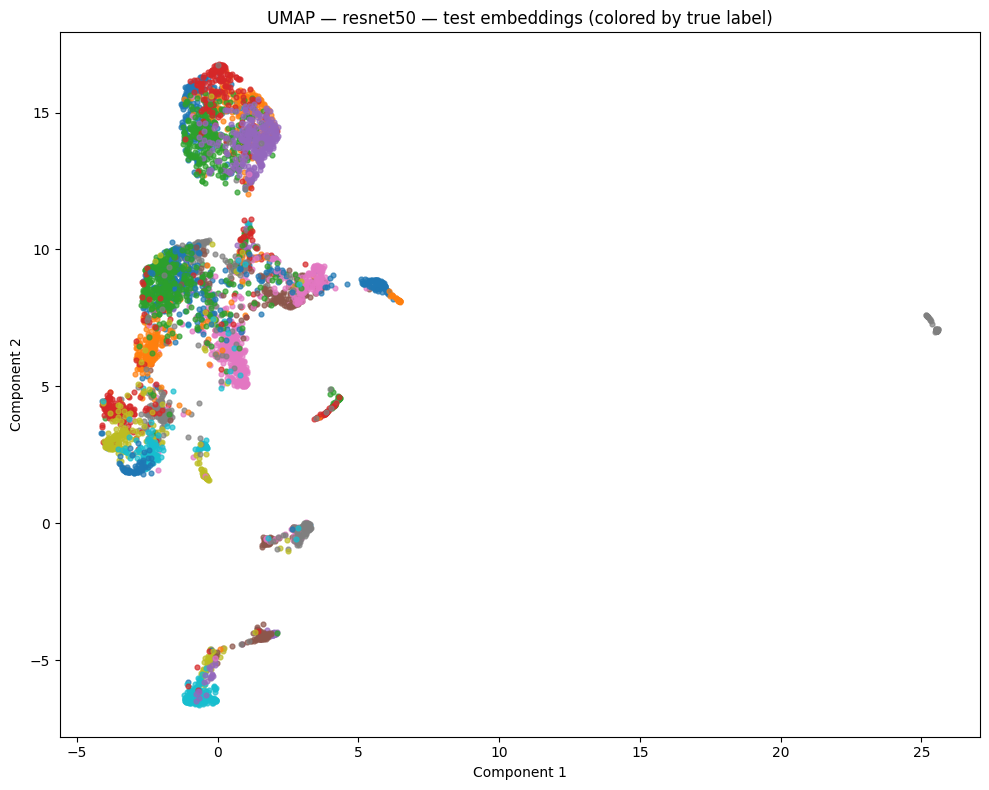

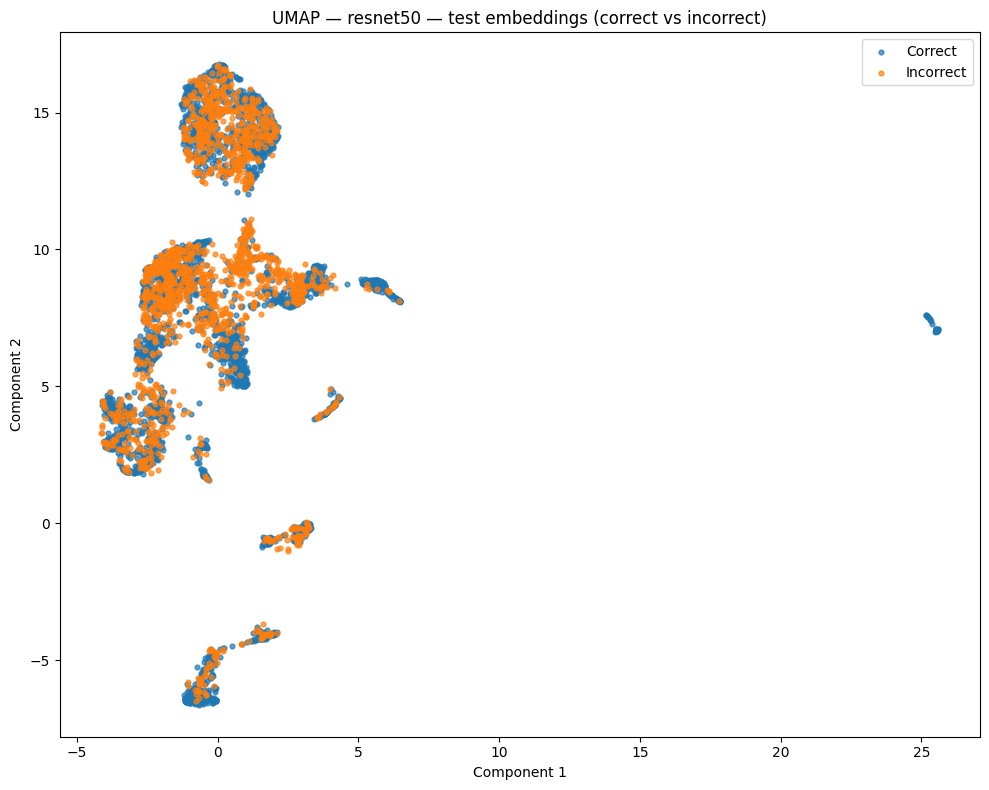


Training classifier for feature: vit_b_16
Raw feature shapes:
  train: (82434, 3072) float32
  val: (27478, 3072) float32
  test: (27478, 3072) float32
  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
  transformed 40960/82434 samples
  transformed 81920/82434 samples
  transformed 82434/82434 samples
  transformed 27478/27478 samples
  transformed 27478/27478 samples
Epoch [01/50] Train Loss: 1.3759 Train Acc: 0.5358 Val Loss: 0.9745 Val Acc: 0.6533
Epoch [02/50] Train Loss: 0.9901 Train Acc: 0.6552 Val Loss: 0.8120 Val Acc: 0.7165
Epoch [03/50] Train Loss: 0.8885 Train Acc: 0.6894 Val Loss: 0.7869 Val Acc: 0.7236
Epoch [04/50] Train Loss: 0.8198 Train Acc: 0.7124 Val Loss: 0.7347 Val Acc: 0.7365
Epoch [05/50] Train Loss: 0.7715 Train Acc: 0.7282 Val Loss: 0.6879 Val Acc: 0.7562
Epoch [06/50] Train Loss: 0.7305 Train Acc: 0.7415 Val Loss: 0.6865 Val Acc: 0.7556
Epoch [07/50] Train Loss: 0.7025 Train Acc: 0.7522 Val L

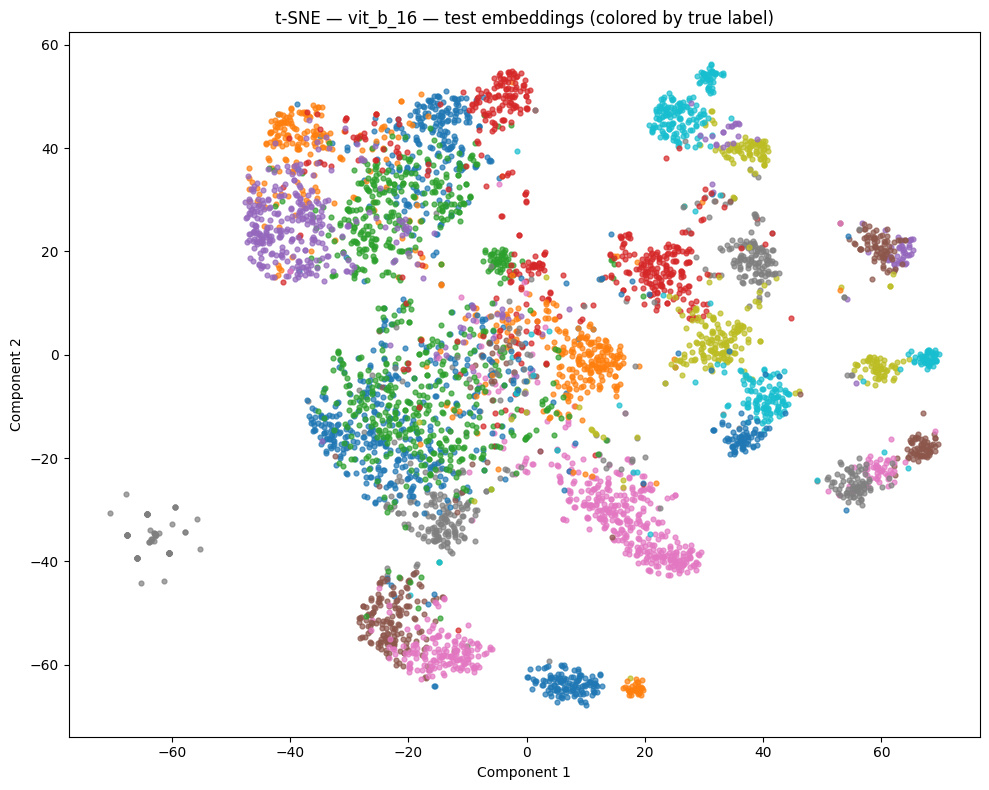

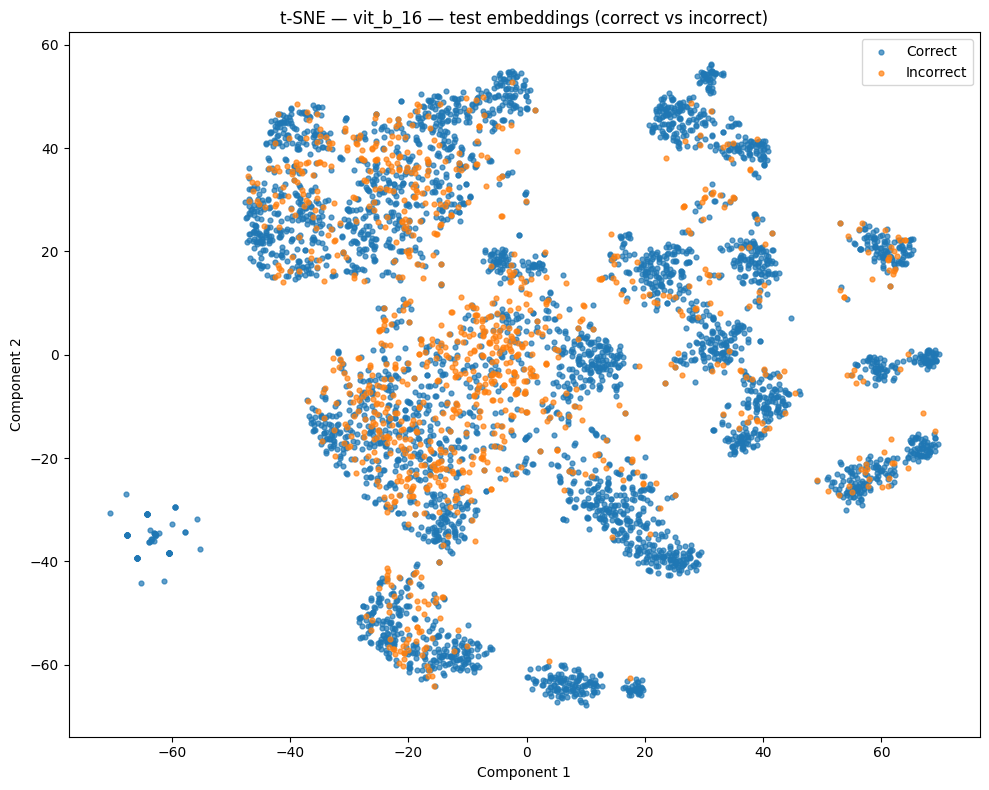

Running UMAP for vit_b_16 (test, n=5000) ...


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


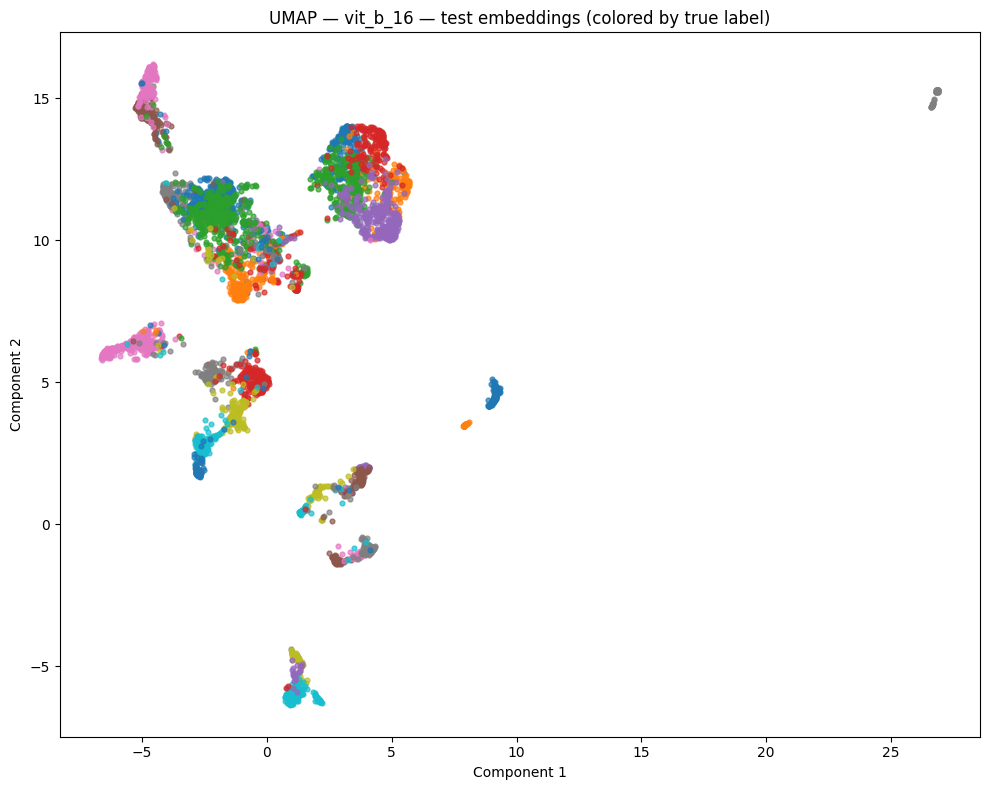

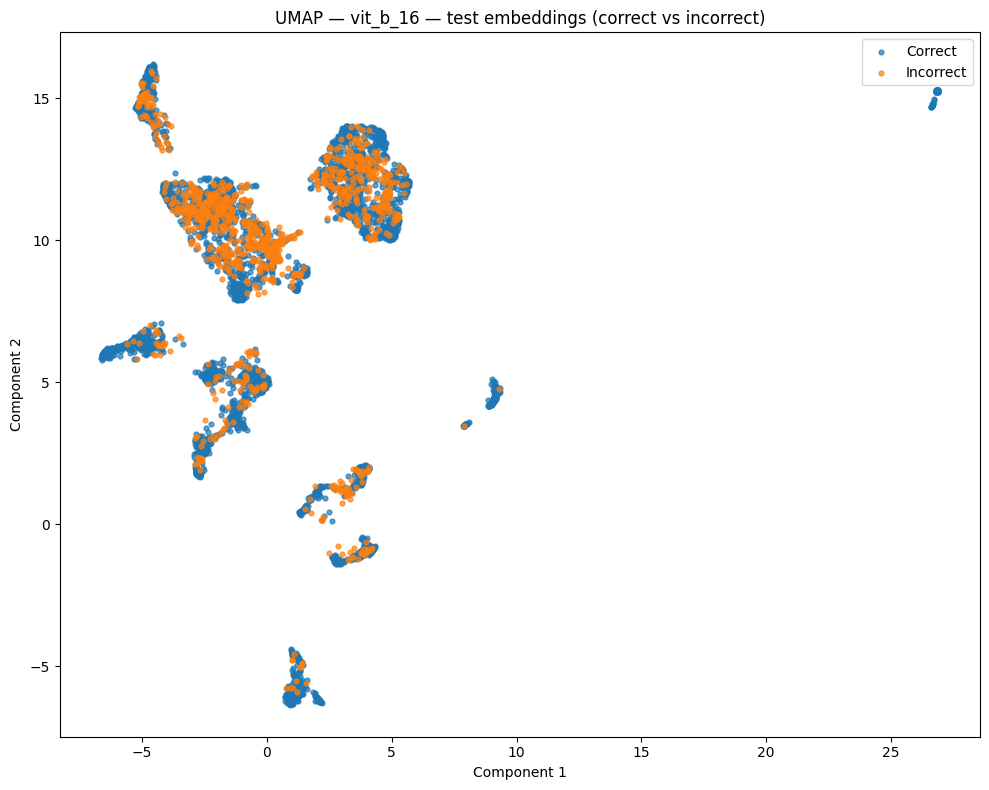


Saved summary to: ..\output\single_feature_classification_results\summary.csv


,feature_name,input_dim,best_epoch,best_val_acc,test_acc,macro_f1,weighted_f1,result_dir
1,densenet121,4096,12,0.814579,0.811158,0.834033,0.811143,..\output\single_feature_classification_result...
5,vit_b_16,3072,43,0.803843,0.803370,0.828232,0.803633,..\output\single_feature_classification_result...
3,mobilenet_v3_large,3840,16,0.766031,0.767851,0.794052,0.767681,..\output\single_feature_classification_result...
2,efficientnet_b0,5120,33,0.759517,0.763302,0.789300,0.763506,..\output\single_feature_classification_result...
4,resnet50,8192,9,0.692190,0.692190,0.722865,0.692357,..\output\single_feature_classification_result...
0,cytoimagenet_efficientnetb0,5120,49,0.561322,0.562559,0.579817,0.558542,..\output\single_feature_classification_result...


In [21]:
summary_rows = []

for feature_folder in feature_folders:
    summary_row = train_classifier_for_feature_folder(feature_folder)
    summary_rows.append(summary_row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("test_acc", ascending=False)

summary_path = RESULTS_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSaved summary to:", summary_path)
display(summary_df)

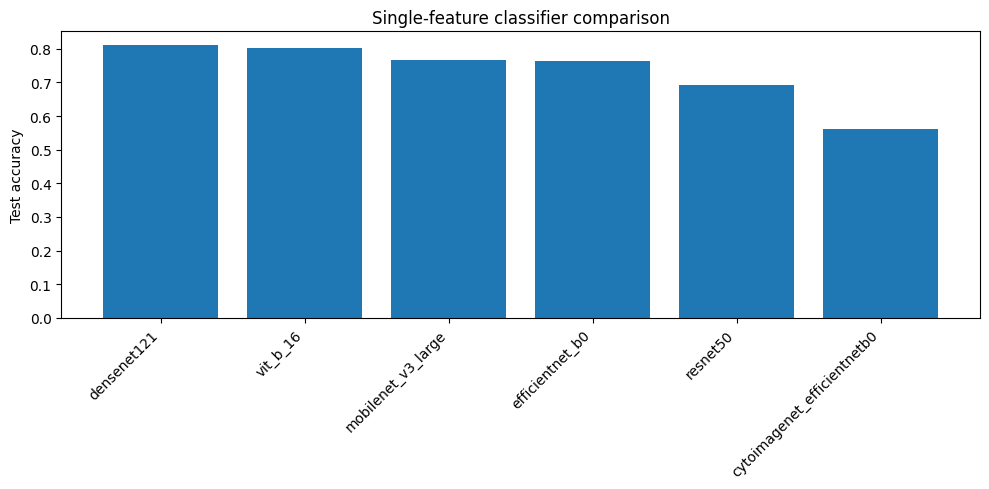

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["feature_name"], summary_df["test_acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy")
plt.title("Single-feature classifier comparison")
plt.tight_layout()
plt.show()


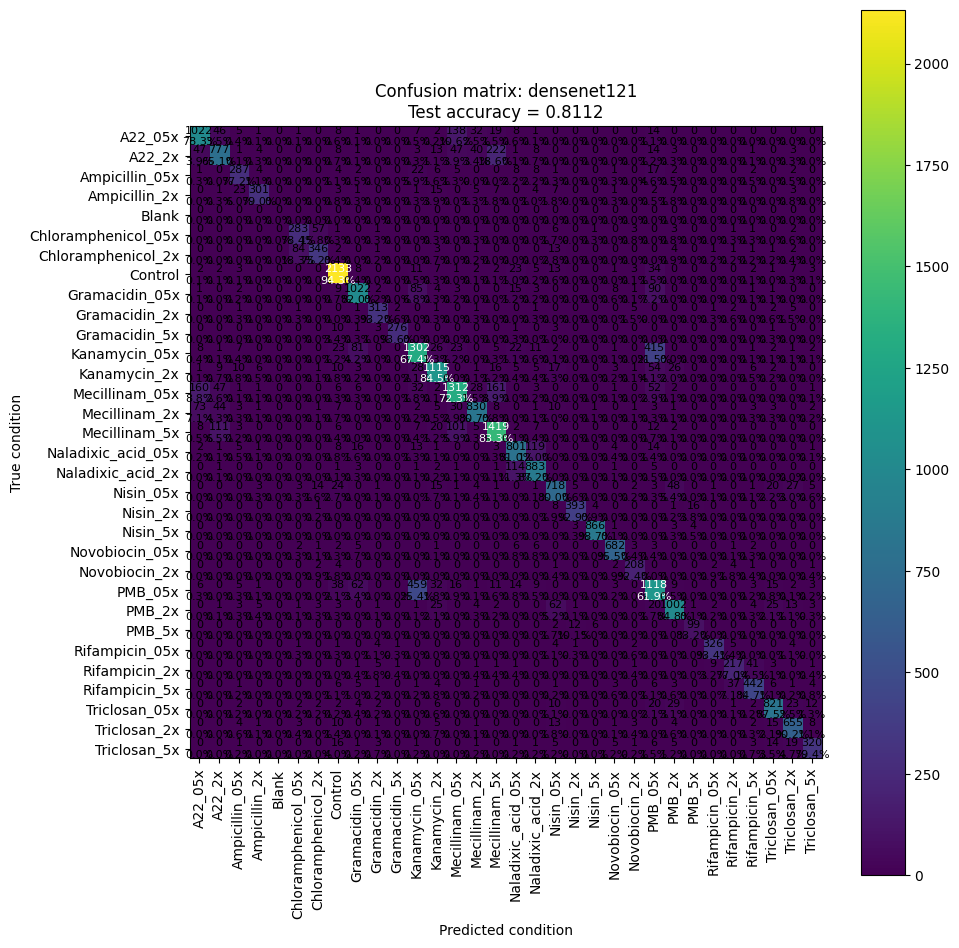

In [23]:
# Optional: display the confusion matrix for the best feature set with counts and row percentages.

best_feature_name = summary_df.iloc[0]["feature_name"]
best_result_dir = RESULTS_DIR / best_feature_name
cm = np.load(best_result_dir / "confusion_matrix.npy")

row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
)

plt.figure(figsize=(10, 10))
plt.imshow(cm)

plt.title(
    f"Confusion matrix: {best_feature_name}\n"
    f"Test accuracy = {summary_df.iloc[0]['test_acc']:.4f}"
)

plt.xlabel("Predicted condition")
plt.ylabel("True condition")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f"{cm[i, j]}\n{cm_percent[i, j] * 100:.1f}%"

        plt.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

In [24]:
# Optional: quickly inspect the visualization outputs for the best feature set.

best_feature_name = summary_df.iloc[0]["feature_name"]
best_result_dir = RESULTS_DIR / best_feature_name

print("Best feature:", best_feature_name)
print("Result directory:", best_result_dir)

for path in sorted(best_result_dir.glob("*tsne*")):
    print(path.name)
for path in sorted(best_result_dir.glob("*umap*")):
    print(path.name)


Best feature: densenet121
Result directory: ..\output\single_feature_classification_results\densenet121
tsne_test_by_correctness.png
tsne_test_by_true_label.png
tsne_test_coordinates.csv
tsne_test_coordinates.npy
umap_test_by_correctness.png
umap_test_by_true_label.png
umap_test_coordinates.csv
umap_test_coordinates.npy
